# Trabajo Práctico Final: Solución de IA Integral
**Materia:** Taller de Lenguajes de Programación III - Python para Ciencia de Datos

**Integrantes:** Escalante Facundo, Bogado Augusto, Rossi Fabiana.

## PASO 1: ENTENDIMIENTO, LIMPIEZA Y EDA

In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

In [ ]:
df = pd.read_csv("data/student-lifestyle-and-stress-dataset.csv")
df.isnull().describe()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,25500,25500,25500,25500,25500,25500,25500,25500,25500
unique,2,2,2,2,2,2,2,2,1
top,False,False,False,False,False,False,False,False,False
freq,24248,24167,24223,24188,24195,24230,24209,24186,25500


In [ ]:
df["Stress_Level"].unique()

array([1, 0])

In [ ]:
df.isnull().info()

<class 'pandas.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Student_Type        25500 non-null  bool 
 1   Sleep_Hours         25500 non-null  bool 
 2   Study_Hours         25500 non-null  bool 
 3   Social_Media_Hours  25500 non-null  bool 
 4   Attendance          25500 non-null  bool 
 5   Exam_Pressure       25500 non-null  bool 
 6   Family_Support      25500 non-null  bool 
 7   Month               25500 non-null  bool 
 8   Stress_Level        25500 non-null  bool 
dtypes: bool(9)
memory usage: 224.2 KB


**Variable objetivo (y):** stress_level

**Características (X):** Columnas restantes

In [ ]:
df.isnull().sum()

Student_Type          1252
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

Se identifica que las columnas nulas en el dataset son de aproximadamente 6% de los datos totales. Debido a la baja proporción de los mismos, se pueden eliminar sin problema pues no se considera que afectará al dataset final.

In [ ]:
df_copia = df.copy()
df_copia = df_copia.dropna()

In [ ]:
df_copia

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1
7,college,6.357065,2.827955,6.198479,74.180341,7.0,8.0,6.0,0
...,...,...,...,...,...,...,...,...,...
25495,college,7.803069,7.328193,2.018277,75.435607,5.0,1.0,12.0,0
25496,school,6.734607,2.680109,3.355559,63.387386,8.0,9.0,2.0,1
25497,college,7.701671,2.631250,2.948252,79.818930,4.0,3.0,4.0,1
25498,school,5.903426,3.450424,6.823894,96.680773,2.0,6.0,6.0,0


In [ ]:
df_copia.isnull().sum()

Student_Type          0
Sleep_Hours           0
Study_Hours           0
Social_Media_Hours    0
Attendance            0
Exam_Pressure         0
Family_Support        0
Month                 0
Stress_Level          0
dtype: int64

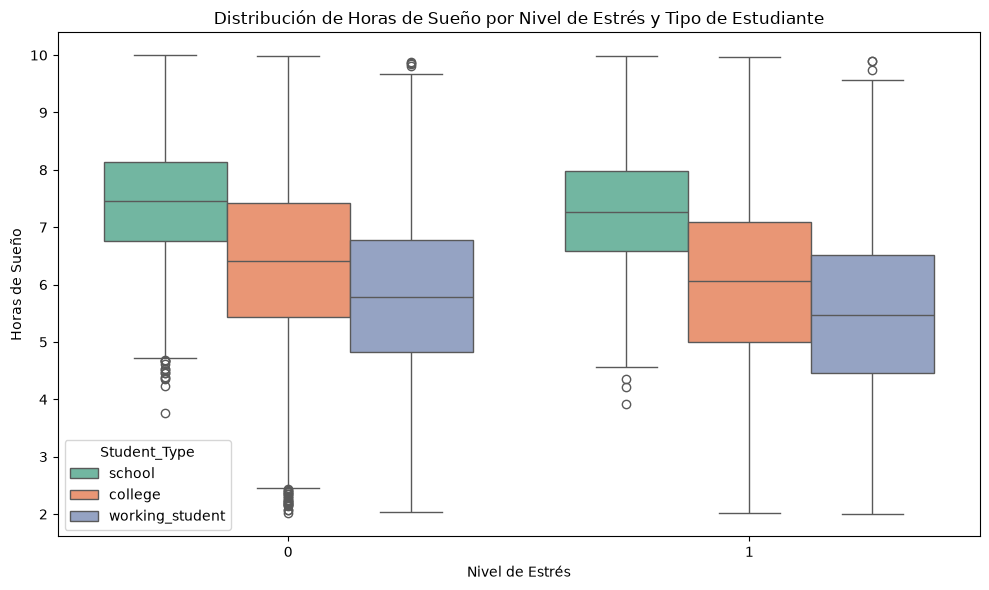

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Stress_Level', y='Sleep_Hours', hue='Student_Type', data=df, palette='Set2')

plt.title('Distribución de Horas de Sueño por Nivel de Estrés y Tipo de Estudiante')
plt.xlabel('Nivel de Estrés')
plt.ylabel('Horas de Sueño')
plt.tight_layout()
plt.show()

## PASO 2: INGENIERÍA DE CARACTERÍSTICAS Y TRANSFORMACIÓN

Aplicamos la propiedad .get_dummies() para las variables nominales in orden jerárquico, para que nuestro dataset sea conformado solamente por datos numéricos.

In [ ]:
df_copia = pd.get_dummies(df_copia, columns=['Student_Type'], prefix='student_type', dtype=int)
df_copia

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level,student_type_college,student_type_school,student_type_working_student
1,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1,0,1,0
2,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1,1,0,0
3,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0,0,1,0
4,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1,1,0,0
7,6.357065,2.827955,6.198479,74.180341,7.0,8.0,6.0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
25495,7.803069,7.328193,2.018277,75.435607,5.0,1.0,12.0,0,1,0,0
25496,6.734607,2.680109,3.355559,63.387386,8.0,9.0,2.0,1,0,1,0
25497,7.701671,2.631250,2.948252,79.818930,4.0,3.0,4.0,1,1,0,0
25498,5.903426,3.450424,6.823894,96.680773,2.0,6.0,6.0,0,0,1,0


Separamios en X y en y lo que queremos predecir y lo dividimos en entrenamiento y testeo.

In [ ]:
X = df_copia.drop(columns=['Stress_Level'])
y = df_copia[['Stress_Level']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Utilizamos StandardScaler para normalizar las escalas de tiempo para evitar los sesgos por magnitud.

In [ ]:
columnas_a_escalar = ['Study_Hours', 'Sleep_Hours']

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train[columnas_a_escalar] = scaler.fit_transform(X_train[columnas_a_escalar])

In [ ]:
X_test[columnas_a_escalar] = scaler.transform(X_test[columnas_a_escalar])

## PASO 3: MODELADO

Modelamos con el RandomForestClassifier

In [ ]:
model = RandomForestClassifier(
    n_estimators= 150,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

c:\Users\IPF-2026\Desktop\Predictwithmodel-tpint\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

## PASO 4: EVALUACIÓN E INTERPRETACIÓN

Empezamos con la evaluación del modelo previamente hecho.

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
acc_score = model.score(X=X_test, y=y_test)
print(f"Accuracy de Random Forest: {acc_score:.4f}")

Accuracy de Random Forest: 0.7989


In [ ]:
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
}).sort_values('Importancia', ascending=False)

print(importancias)

                       Variable  Importancia
4                 Exam_Pressure     0.545034
1                   Study_Hours     0.140823
0                   Sleep_Hours     0.080486
2            Social_Media_Hours     0.073018
3                    Attendance     0.058324
5                Family_Support     0.044689
6                         Month     0.036812
8           student_type_school     0.011149
9  student_type_working_student     0.005395
7          student_type_college     0.004271


Hacemos un reporte de clasificación del modelo.

In [ ]:
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      2366
           1       0.63      0.76      0.69       996

    accuracy                           0.80      3362
   macro avg       0.76      0.79      0.77      3362
weighted avg       0.81      0.80      0.80      3362



Dibujamos un gráfico del modelo final.

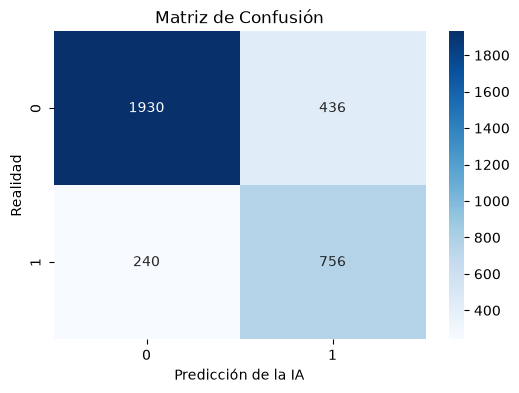

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Realidad')
plt.xlabel('Predicción de la IA')
plt.show()

## PASO 5: EXPORTACIÓN FINAL

Exportamos el modelo final para utilizarlo en la pàgina web.

In [ ]:
joblib.dump(model, 'models/modelo_final.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

In [ ]:
modelo_RL = LinearRegression()
modelo_RL.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 10)","[[-0.04, 0.09, 0.02,...,-0. , 0. , 0. ]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['Sleep_Hours','Study_Hours','Social_Media_Hours',..., 'student_type_college','student_type_school', 'student_type_working_student']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.03]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [ ]:
y_pred_RL = modelo_RL.predict(X_test)

In [ ]:
acc_score_RL = modelo_RL.score(X=X_test, y=y_test)
print(f"Accuracy de Regresión Lineal: {acc_score_RL:.4f}")

Accuracy de Regresión Lineal: 0.3477


In [ ]:
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_train, y_train)

c:\Users\IPF-2026\Desktop\Predictwithmodel-tpint\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\IPF-2026\Desktop\Predictwithmodel-tpint\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [ ]:
y_pred_Logistico = modelo_logistico.predict(X_test)
acc_score_Logistico = modelo_logistico.score(X=X_test, y=y_test)
print(f"Accuracy de Regresión Logística: {acc_score_Logistico:.4f}")

Accuracy de Regresión Logística: 0.8260


In [ ]:
print(classification_report(y_test, y_pred_Logistico))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      2366
           1       0.74      0.63      0.68       996

    accuracy                           0.83      3362
   macro avg       0.80      0.77      0.78      3362
weighted avg       0.82      0.83      0.82      3362



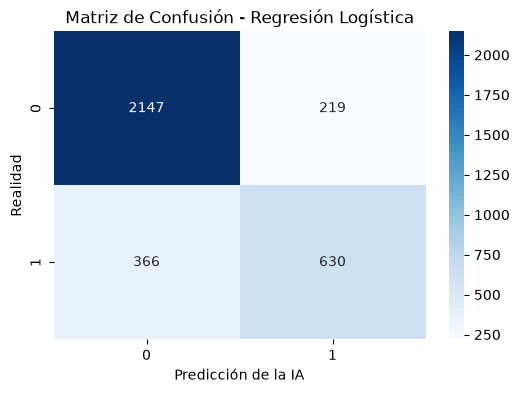

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_Logistico), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.ylabel('Realidad')
plt.xlabel('Predicción de la IA')
plt.show()

In [ ]:
joblib.dump(modelo_logistico, 'models/modelo_logistico.pkl')